# Modelado operacional mensual de clasificacion

## Proposito de esta fase

Esta etapa traslada la logica de clasificacion anual hacia una capa mensual operativa, con el fin de construir una senal utilizable para alertas, seguimiento intra-anual y eventual integracion con el trigger del seguro indexado. La meta no es reemplazar la validacion principal anual, sino complementar el proyecto con una salida mensual interpretable y accionable.

## Enfoque metodologico

- Se usa la base mensual limpia como insumo operacional.
- Se usa la variable anual de evento como referencia supervisada.
- Se prueban dos muestras operativas: panel mensual completo y meses de cosecha.
- Se prueban varios conjuntos de variables mensuales, incluyendo rezagos y promedios moviles.
- La evaluacion principal se hace agregando probabilidades mensuales a nivel departamento-anio, para contrastarlas con el evento anual observado.
- Se conserva una lectura auxiliar a nivel mensual, entendida como metrica proxy, no como verdad observada mensual independiente.


In [4]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

RANDOM_STATE = 42
TARGET = 'evento_perdida_anual'
TRAIN_END_YEAR = 2020
TEST_START_YEAR = 2021
TEST_END_YEAR = 2024
CV_MIN_TRAIN_YEARS = 4
CV_VALID_WINDOW = 2
THRESHOLDS = [round(x, 2) for x in np.arange(0.10, 0.91, 0.05)]
AGGREGATION_STRATEGIES = ['max', 'weighted_mean']

RUN_LOG = []

def log(message):
    print(message)
    RUN_LOG.append(str(message))

def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    for candidate in [current, *current.parents]:
        if (candidate / 'BASE_DE_DATOS').exists() and (candidate / 'MODELOS').exists():
            return candidate
    return current

PROJECT_ROOT = find_project_root()
MONTHLY_PATH = PROJECT_ROOT / 'BASE_DE_DATOS' / 'FINALES' / 'dataset_operativo_mensual_limpio.csv'
ANNUAL_PATH = PROJECT_ROOT / 'BASE_DE_DATOS' / 'FINALES' / 'dataset_modelado_anual_limpio.csv'
OUTPUT_DIR = PROJECT_ROOT / 'MODELOS' / 'resultados_11_1_operacional_mensual_clasificacion'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Raiz del proyecto detectada: {PROJECT_ROOT}')
print(f'Carpeta de resultados: {OUTPUT_DIR.name}')


Raiz del proyecto detectada: C:\Users\crist\Documents\MAESTRIA\PROYECTO_GRADO
Carpeta de resultados: resultados_11_1_operacional_mensual_clasificacion


In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.model_selection import ParameterGrid
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except Exception:
    MATPLOTLIB_AVAILABLE = False

try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except Exception:
    SEABORN_AVAILABLE = False

try:
    from imblearn.over_sampling import RandomOverSampler
    from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
    IMBLEARN_AVAILABLE = True
except Exception:
    IMBLEARN_AVAILABLE = False

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False

DEPENDENCIES = pd.DataFrame([
    {'libreria': 'matplotlib', 'disponible': MATPLOTLIB_AVAILABLE},
    {'libreria': 'seaborn', 'disponible': SEABORN_AVAILABLE},
    {'libreria': 'imbalanced-learn', 'disponible': IMBLEARN_AVAILABLE},
    {'libreria': 'xgboost', 'disponible': XGBOOST_AVAILABLE},
    {'libreria': 'lightgbm', 'disponible': LIGHTGBM_AVAILABLE},
])

display(DEPENDENCIES)


,libreria,disponible
0,matplotlib,True
1,seaborn,True
2,imbalanced-learn,True
3,xgboost,True
4,lightgbm,True


## Carga de bases finales

Las dos capas finales del proyecto cumplen funciones complementarias:

- La capa anual conserva la referencia observada de evento y sigue siendo la base principal de validacion.
- La capa mensual aporta resolucion temporal, estacionalidad, rezagos y una salida operacional alineada con el dashboard y la logica de alerta.


In [6]:
def read_csv_auto(path_obj):
    path_obj = Path(path_obj)
    first_line = path_obj.open('r', encoding='utf-8').readline()
    sep = ';' if first_line.count(';') > first_line.count(',') else ','
    return pd.read_csv(path_obj, sep=sep)

monthly = read_csv_auto(MONTHLY_PATH)
annual = read_csv_auto(ANNUAL_PATH)

if 'fecha' in monthly.columns:
    monthly['fecha'] = pd.to_datetime(monthly['fecha'], errors='coerce')
else:
    raise ValueError("La base mensual no contiene la columna 'fecha' despues de la lectura.")

if 'fecha' in annual.columns:
    annual['fecha'] = pd.to_datetime(annual['fecha'], errors='coerce')

if 'es_risaralda' not in monthly.columns:
    monthly['es_risaralda'] = (monthly['departamento'].astype(str).str.lower() == 'risaralda').astype(int)

if 'es_risaralda' not in annual.columns:
    annual['es_risaralda'] = (annual['departamento'].astype(str).str.lower() == 'risaralda').astype(int)

required_annual_cols = ['departamento', 'anio', TARGET]
missing_annual = [c for c in required_annual_cols if c not in annual.columns]
assert not missing_annual, f'Faltan columnas anuales requeridas: {missing_annual}'

annual_target = annual[['departamento', 'anio', TARGET, 'perdida_rendimiento_anual_pct']].copy()
monthly = monthly.merge(annual_target, on=['departamento', 'anio'], how='left')

source_summary = pd.DataFrame([
    {'base': 'mensual_operativa', 'filas': len(monthly), 'columnas': monthly.shape[1], 'anio_min': int(monthly['anio'].min()), 'anio_max': int(monthly['anio'].max())},
    {'base': 'anual_modelado', 'filas': len(annual), 'columnas': annual.shape[1], 'anio_min': int(annual['anio'].min()), 'anio_max': int(annual['anio'].max())},
])

display(source_summary)


,base,filas,columnas,anio_min,anio_max
0,mensual_operativa,628,63,2000,2026
1,anual_modelado,36,81,2007,2024


## Preparacion operacional mensual

La capa mensual se enriquece con dos tipos de transformaciones:

1. Variables estacionales, que permiten representar la posicion dentro del anio y el rol de los meses de cosecha.
2. Variables dinamicas con memoria reciente, mediante rezagos y promedios moviles, para capturar persistencia climatica y satelital.

Estas transformaciones permiten que el modelo operacional no dependa unicamente del estado puntual del mes, sino tambien de su contexto reciente.


In [7]:
monthly = monthly.sort_values(['departamento', 'fecha']).reset_index(drop=True)
monthly['mes'] = monthly['mes'].astype(int)
monthly['mes_sin'] = np.sin(2 * np.pi * monthly['mes'] / 12.0)
monthly['mes_cos'] = np.cos(2 * np.pi * monthly['mes'] / 12.0)
monthly['es_mes_cosecha'] = monthly['es_mes_cosecha'].fillna(0).astype(int)
monthly['factor_mensual'] = monthly['factor_mensual'].fillna(0.0)

lag_source_cols = [
    'precipitation', 'temp_aire_C', 'def', 'GDD_cafe',
    'NDVI', 'EVI', 'Gpp', 'NDVI_anomalia_pct', 'EVI_anomalia_pct', 'Gpp_anomalia_pct',
    'precio_ico_usd_ton', 'precio_productor_usd_ton'
]
lag_source_cols = [c for c in lag_source_cols if c in monthly.columns]

for col in lag_source_cols:
    monthly[f'{col}_lag1'] = monthly.groupby('departamento')[col].shift(1)
    monthly[f'{col}_lag2'] = monthly.groupby('departamento')[col].shift(2)
    monthly[f'{col}_roll3'] = monthly.groupby('departamento')[col].transform(lambda s: s.shift(1).rolling(3, min_periods=2).mean())

monthly['ventana_supervisada'] = monthly['anio'].between(int(annual['anio'].min()), int(annual['anio'].max())).astype(int)

engineered_preview_cols = [
    c for c in ['departamento', 'fecha', 'mes', 'mes_sin', 'mes_cos', 'es_mes_cosecha', 'factor_mensual'] if c in monthly.columns
] + [c for c in monthly.columns if c.endswith('_lag1')][:4] + [c for c in monthly.columns if c.endswith('_roll3')][:4]

display(monthly[engineered_preview_cols].head(12))


,departamento,fecha,mes,mes_sin,mes_cos,es_mes_cosecha,factor_mensual,precipitation_lag1,temp_aire_C_lag1,def_lag1,GDD_cafe_lag1,precipitation_roll3,temp_aire_C_roll3,def_roll3,GDD_cafe_roll3
0,Cundinamarca,2000-01-01,1,5.000000e-01,8.660254e-01,0,0.042105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Cundinamarca,2000-02-01,2,8.660254e-01,5.000000e-01,0,0.036842,58.122070,16.040529,87.170530,7.203958,NaN,NaN,NaN,NaN
2,Cundinamarca,2000-03-01,3,1.000000e+00,6.123234e-17,0,0.047368,102.480240,16.364601,4.391722,7.418556,80.301155,16.202565,45.781126,7.311257
3,Cundinamarca,2000-04-01,4,8.660254e-01,-5.000000e-01,1,0.078947,126.669177,16.723544,24.697898,7.621710,95.757162,16.376224,38.753383,7.414741
4,Cundinamarca,2000-05-01,5,5.000000e-01,-8.660254e-01,1,0.094737,146.966135,16.678842,11.807117,7.806545,125.371851,16.588995,13.632246,7.615604
5,Cundinamarca,2000-06-01,6,1.224647e-16,-1.000000e+00,1,0.084211,238.109657,16.730210,0.000000,7.702863,170.581656,16.710865,12.168338,7.710373
6,Cundinamarca,2000-07-01,7,-5.000000e-01,-8.660254e-01,0,0.057895,157.276865,16.506542,0.000000,7.442207,180.784219,16.638531,3.935706,7.650538
7,Cundinamarca,2000-08-01,8,-8.660254e-01,-5.000000e-01,0,0.052632,140.563312,16.195465,5.516779,7.184484,178.649945,16.477406,1.838926,7.443185
8,Cundinamarca,2000-09-01,9,-1.000000e+00,-1.836970e-16,0,0.063158,133.568160,16.682672,46.696576,7.707375,143.802779,16.461560,17.404452,7.444689
9,Cundinamarca,2000-10-01,10,-8.660254e-01,5.000000e-01,1,0.126316,173.115534,16.667524,0.000000,7.354164,149.082335,16.515220,17.404452,7.415341


In [8]:
observed_monthly = monthly.loc[monthly[TARGET].notna() & monthly['anio'].between(int(annual['anio'].min()), int(annual['anio'].max()))].copy()
observed_monthly[TARGET] = observed_monthly[TARGET].astype(int)

sample_catalog = {
    'mensual_completo': observed_monthly.copy(),
    'solo_cosecha': observed_monthly.loc[observed_monthly['es_mes_cosecha'] == 1].copy(),
}

sample_summary_rows = []
for sample_name, sample_df in sample_catalog.items():
    annual_groups = sample_df[['departamento', 'anio', TARGET]].drop_duplicates()
    sample_summary_rows.append({
        'muestra': sample_name,
        'filas_mensuales': len(sample_df),
        'grupos_departamento_anio': len(annual_groups),
        'eventos_anuales': int(annual_groups[TARGET].sum()),
        'share_evento_anual': float(annual_groups[TARGET].mean()),
        'anios_min': int(sample_df['anio'].min()),
        'anios_max': int(sample_df['anio'].max()),
    })

sample_summary = pd.DataFrame(sample_summary_rows)
display(sample_summary)


,muestra,filas_mensuales,grupos_departamento_anio,eventos_anuales,share_evento_anual,anios_min,anios_max
0,mensual_completo,432,36,7,0.194444,2007,2024
1,solo_cosecha,216,36,7,0.194444,2007,2024


## Division temporal y validacion

La evaluacion mantiene una logica temporal estricta:

- Entrenamiento principal: 2007-2020
- Prueba final: 2021-2024

Dentro del entrenamiento, se usa validacion expansiva por bloques de anios. El objetivo de esta decision es aproximar un escenario realista de despliegue, evitando fugas temporales y evaluando la capacidad del modelo para generalizar hacia anios futuros.


In [9]:
def make_expanding_year_folds(years, min_train_years=4, valid_window=2):
    years = sorted(int(y) for y in years)
    folds = []
    for start_idx in range(min_train_years, len(years) - valid_window + 1):
        train_years = years[:start_idx]
        valid_years = years[start_idx:start_idx + valid_window]
        folds.append({'train_years': train_years, 'valid_years': valid_years})
    return folds

train_years = sorted(observed_monthly.loc[observed_monthly['anio'] <= TRAIN_END_YEAR, 'anio'].dropna().astype(int).unique().tolist())
folds = make_expanding_year_folds(train_years, min_train_years=CV_MIN_TRAIN_YEARS, valid_window=CV_VALID_WINDOW)

fold_summary_rows = []
for fold in folds:
    valid_annual = annual.loc[annual['anio'].isin(fold['valid_years']), ['departamento', 'anio', TARGET]].drop_duplicates()
    train_annual = annual.loc[annual['anio'].isin(fold['train_years']), ['departamento', 'anio', TARGET]].drop_duplicates()
    fold_summary_rows.append({
        'train_years': ', '.join(map(str, fold['train_years'])),
        'valid_years': ', '.join(map(str, fold['valid_years'])),
        'n_train': len(train_annual),
        'n_valid': len(valid_annual),
        'positivos_train': int(train_annual[TARGET].sum()),
        'positivos_valid': int(valid_annual[TARGET].sum()),
    })

fold_summary = pd.DataFrame(fold_summary_rows)
display(fold_summary)


,train_years,valid_years,n_train,n_valid,positivos_train,positivos_valid
0,"2007, 2008, 2009, 2010","2011, 2012",8,4,1,1
1,"2007, 2008, 2009, 2010, 2011","2012, 2013",10,4,1,3
2,"2007, 2008, 2009, 2010, 2011, 2012","2013, 2014",12,4,2,3
3,"2007, 2008, 2009, 2010, 2011, 2012, 2013","2014, 2015",14,4,4,1
4,"2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014","2015, 2016",16,4,5,0
5,"2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014...","2016, 2017",18,4,5,0
6,"2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014...","2017, 2018",20,4,5,0
7,"2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014...","2018, 2019",22,4,5,0
8,"2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014...","2019, 2020",24,4,5,0


## Conjuntos de variables operacionales

Se definieron varios grupos de variables para contrastar diferentes niveles de complejidad:

- Un bloque mensual base, con informacion climatica, satelital, estacional, economica y de terreno.
- Un bloque ampliado con memoria temporal, incorporando rezagos y promedios moviles.
- Un bloque mas enfocado en cosecha, priorizando senales mas cercanas a la logica operacional del seguro.

Esta comparacion permite analizar si la senal adicional de memoria temporal realmente mejora la deteccion de eventos relevantes.


In [10]:
core_static = [
    'es_risaralda', 'mes', 'mes_sin', 'mes_cos', 'es_mes_cosecha', 'factor_mensual',
    'precio_ico_usd_ton', 'precio_productor_usd_ton', 'elevacion_media_m', 'pendiente_media'
]
core_dynamic = [
    'precipitation', 'temp_aire_C', 'def', 'GDD_cafe',
    'NDVI', 'EVI', 'Gpp', 'NDVI_anomalia_pct', 'EVI_anomalia_pct', 'Gpp_anomalia_pct'
]
core_static = [c for c in core_static if c in monthly.columns]
core_dynamic = [c for c in core_dynamic if c in monthly.columns]

lag_features = [c for c in monthly.columns if c.endswith('_lag1') or c.endswith('_lag2') or c.endswith('_roll3')]
lag_features = sorted(lag_features)

feature_sets = {
    'mensual_core': [c for c in core_static + core_dynamic if c in observed_monthly.columns],
    'mensual_core_lags': [c for c in core_static + core_dynamic + lag_features if c in observed_monthly.columns],
    'mensual_cosecha_focus': [
        c for c in (
            ['es_risaralda', 'mes', 'mes_sin', 'mes_cos', 'es_mes_cosecha', 'factor_mensual', 'precio_ico_usd_ton', 'precio_productor_usd_ton',
             'temp_aire_C', 'def', 'GDD_cafe', 'NDVI', 'EVI', 'Gpp', 'NDVI_anomalia_pct', 'EVI_anomalia_pct', 'Gpp_anomalia_pct']
            + [c for c in lag_features if any(tag in c for tag in ['temp_aire_C', 'def', 'NDVI', 'EVI', 'Gpp'])]
        ) if c in observed_monthly.columns
    ],
}

feature_set_summary = pd.DataFrame([
    {
        'feature_set': name,
        'n_features': len(cols),
        'primeras_variables': ', '.join(cols[:12]) + ('...' if len(cols) > 12 else '')
    }
    for name, cols in feature_sets.items()
])

display(feature_set_summary)


,feature_set,n_features,primeras_variables
0,mensual_core,20,"es_risaralda, mes, mes_sin, mes_cos, es_mes_co..."
1,mensual_core_lags,56,"es_risaralda, mes, mes_sin, mes_cos, es_mes_co..."
2,mensual_cosecha_focus,41,"es_risaralda, mes, mes_sin, mes_cos, es_mes_co..."


In [11]:
def sigmoid(x):
    x = np.clip(np.asarray(x, dtype=float), -30, 30)
    return 1.0 / (1.0 + np.exp(-x))

def classification_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    accuracy = (tp + tn) / max(len(y_true), 1)
    recall = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)
    precision = tp / max(tp + fp, 1)
    f1 = 0.0 if (precision + recall) == 0 else 2 * precision * recall / (precision + recall)
    balanced_accuracy = (recall + specificity) / 2.0
    try:
        roc_auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) > 1 else np.nan
    except Exception:
        roc_auc = np.nan
    return {
        'accuracy': float(accuracy),
        'balanced_accuracy': float(balanced_accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'f1': float(f1),
        'roc_auc': float(roc_auc) if not pd.isna(roc_auc) else np.nan,
        'positive_rate_pred': float(y_pred.mean()) if len(y_pred) else np.nan,
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
    }

def annualize_monthly_scores(pred_df, aggregation='max'):
    work = pred_df.copy()
    work['factor_eval'] = work['factor_mensual'].fillna(0.0) if 'factor_mensual' in work.columns else 0.0
    grouped = []
    for (depto, anio), grp in work.groupby(['departamento', 'anio'], dropna=False):
        y_true = int(grp[TARGET].iloc[0])
        if aggregation == 'max':
            score = float(np.nanmax(grp['y_score'].values))
        elif aggregation == 'weighted_mean':
            w = grp['factor_eval'].astype(float).values
            s = grp['y_score'].astype(float).values
            if np.nansum(w) > 0:
                score = float(np.nansum(s * w) / np.nansum(w))
            else:
                score = float(np.nanmean(s))
        else:
            raise ValueError(f'Agregacion no soportada: {aggregation}')
        grouped.append({
            'departamento': depto,
            'anio': int(anio),
            TARGET: y_true,
            'score_annualized': score,
            'n_meses': int(len(grp)),
            'share_alerta_050': float((grp['y_score'] >= 0.5).mean()),
            'score_max': float(np.nanmax(grp['y_score'].values)),
            'score_mean': float(np.nanmean(grp['y_score'].values)),
        })
    return pd.DataFrame(grouped)

def choose_best_threshold(fold_payloads, thresholds):
    rows = []
    for thr in thresholds:
        metrics_all = []
        metrics_event = []
        for payload in fold_payloads:
            metrics = classification_metrics(payload['y_true'], payload['y_score'], threshold=thr)
            metrics_all.append(metrics)
            if int(np.sum(payload['y_true'])) > 0:
                metrics_event.append(metrics)
        if not metrics_all:
            continue
        row = {
            'threshold': float(thr),
            'cv_accuracy_mean': float(np.nanmean([m['accuracy'] for m in metrics_all])),
            'cv_balanced_accuracy_mean': float(np.nanmean([m['balanced_accuracy'] for m in metrics_all])),
            'cv_precision_mean': float(np.nanmean([m['precision'] for m in metrics_all])),
            'cv_recall_mean': float(np.nanmean([m['recall'] for m in metrics_all])),
            'cv_f1_mean': float(np.nanmean([m['f1'] for m in metrics_all])),
            'cv_roc_auc_mean': float(np.nanmean([m['roc_auc'] for m in metrics_all])) if any(not pd.isna(m['roc_auc']) for m in metrics_all) else np.nan,
            'cv_event_folds': int(len(metrics_event)),
            'cv_recall_event_mean': float(np.nanmean([m['recall'] for m in metrics_event])) if metrics_event else np.nan,
            'cv_precision_event_mean': float(np.nanmean([m['precision'] for m in metrics_event])) if metrics_event else np.nan,
            'cv_f1_event_mean': float(np.nanmean([m['f1'] for m in metrics_event])) if metrics_event else np.nan,
        }
        rows.append(row)
    thr_df = pd.DataFrame(rows)
    if len(thr_df) == 0:
        return None, thr_df
    thr_df = thr_df.sort_values(
        ['cv_f1_event_mean', 'cv_recall_event_mean', 'cv_balanced_accuracy_mean', 'cv_precision_event_mean', 'threshold'],
        ascending=[False, False, False, False, True],
        na_position='last'
    ).reset_index(drop=True)
    return thr_df.iloc[0].to_dict(), thr_df


In [12]:
smoke_sample = sample_catalog['solo_cosecha'].copy()
smoke_features = feature_sets['mensual_core']
smoke_train = smoke_sample.loc[smoke_sample['anio'] <= 2016].dropna(subset=smoke_features + [TARGET]).copy()
smoke_valid = smoke_sample.loc[smoke_sample['anio'].isin([2017, 2018])].dropna(subset=smoke_features + [TARGET]).copy()

if len(smoke_train) > 0 and len(smoke_valid) > 0 and smoke_train[TARGET].nunique() > 1:
    scaler = StandardScaler()
    X_train = scaler.fit_transform(smoke_train[smoke_features])
    X_valid = scaler.transform(smoke_valid[smoke_features])
    smoke_model = LogisticRegression(C=1.0, class_weight='balanced', penalty='l2', solver='lbfgs', max_iter=4000, random_state=RANDOM_STATE)
    smoke_model.fit(X_train, smoke_train[TARGET])
    smoke_valid = smoke_valid.copy()
    smoke_valid['y_score'] = smoke_model.predict_proba(X_valid)[:, 1]
    smoke_annual = annualize_monthly_scores(smoke_valid[['departamento', 'anio', TARGET, 'y_score', 'factor_mensual']].copy(), aggregation='max')
    smoke_metrics = classification_metrics(smoke_annual[TARGET], smoke_annual['score_annualized'], threshold=0.5)
    display(pd.DataFrame([smoke_metrics]))
else:
    print('Smoke test no concluyente: la muestra reducida no tuvo ambas clases suficientes.')


,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,positive_rate_pred,tp,fp,fn,tn
0,0.25,0.125,0.0,0.0,0.25,0.0,NaN,0.75,0,3,0,1


## Modelos operacionales de clasificacion

Se comparan varias familias de clasificadores con el fin de equilibrar sensibilidad a eventos, estabilidad y capacidad de generalizacion:

- Modelos lineales y regularizados, por su interpretabilidad y control sobre el desbalance.
- Modelos basados en arboles y boosting, por su flexibilidad para capturar relaciones no lineales.
- Redes neuronales sencillas, como referencia de una familia mas flexible.
- Ensambles balanceados y remuestreo, cuando las dependencias estan disponibles, para enfrentar mejor la rareza relativa de los eventos.


In [13]:
model_specs = [
    {'model_name': 'DummyClassifier_prior', 'family': 'baseline_simple', 'sampling_strategy': 'none', 'param_grid': [{}]},
    {'model_name': 'LogisticRegression_l2_balanced', 'family': 'lineal', 'sampling_strategy': 'none', 'param_grid': list(ParameterGrid({'C': [0.2, 0.5, 1.0, 2.0]}))},
    {'model_name': 'LogisticRegression_l1_balanced', 'family': 'lineal_regularizado', 'sampling_strategy': 'none', 'param_grid': list(ParameterGrid({'C': [0.2, 0.5, 1.0]}))},
    {'model_name': 'RidgeClassifier_balanced', 'family': 'lineal', 'sampling_strategy': 'none', 'param_grid': list(ParameterGrid({'alpha': [0.5, 1.0, 3.0]}))},
    {'model_name': 'RandomForest_balanced', 'family': 'arboles', 'sampling_strategy': 'none', 'param_grid': list(ParameterGrid({'n_estimators': [200, 400], 'max_depth': [3, None], 'min_samples_leaf': [1, 3]}))},
    {'model_name': 'ExtraTrees_balanced', 'family': 'arboles', 'sampling_strategy': 'none', 'param_grid': list(ParameterGrid({'n_estimators': [200, 400], 'max_depth': [3, None], 'min_samples_leaf': [1, 3]}))},
    {'model_name': 'GradientBoostingClassifier', 'family': 'boosting', 'sampling_strategy': 'none', 'param_grid': list(ParameterGrid({'n_estimators': [100, 150], 'learning_rate': [0.03, 0.05], 'max_depth': [2, 3], 'min_samples_leaf': [1, 2]}))},
    {'model_name': 'HistGradientBoostingClassifier', 'family': 'boosting', 'sampling_strategy': 'none', 'param_grid': list(ParameterGrid({'max_depth': [2, 3], 'learning_rate': [0.03, 0.05], 'max_iter': [150, 250], 'min_samples_leaf': [2, 4]}))},
    {'model_name': 'AdaBoostClassifier', 'family': 'boosting', 'sampling_strategy': 'none', 'param_grid': list(ParameterGrid({'n_estimators': [100, 200], 'learning_rate': [0.03, 0.05, 0.1]}))},
    {'model_name': 'MLPClassifier_shallow', 'family': 'red_neuronal', 'sampling_strategy': 'none', 'param_grid': list(ParameterGrid({'hidden_layer_sizes': [(8,), (16,)], 'alpha': [0.0005, 0.005], 'learning_rate_init': [0.001, 0.01]}))},
]

if IMBLEARN_AVAILABLE:
    model_specs.extend([
        {'model_name': 'LogisticRegression_l2_ros', 'family': 'lineal_balanceado', 'sampling_strategy': 'random_oversample', 'param_grid': list(ParameterGrid({'C': [0.2, 0.5, 1.0]}))},
        {'model_name': 'RidgeClassifier_ros', 'family': 'lineal_balanceado', 'sampling_strategy': 'random_oversample', 'param_grid': list(ParameterGrid({'alpha': [0.5, 1.0, 3.0]}))},
        {'model_name': 'BalancedRandomForest', 'family': 'arboles_balanceados', 'sampling_strategy': 'none', 'param_grid': list(ParameterGrid({'n_estimators': [200, 400], 'max_depth': [3, None], 'min_samples_leaf': [1, 2]}))},
        {'model_name': 'EasyEnsemble', 'family': 'ensamble_balanceado', 'sampling_strategy': 'none', 'param_grid': list(ParameterGrid({'n_estimators': [10, 20]}))},
    ])

if XGBOOST_AVAILABLE:
    model_specs.append({
        'model_name': 'XGBoostClassifier_auto_weight',
        'family': 'boosting',
        'sampling_strategy': 'none',
        'param_grid': list(ParameterGrid({'n_estimators': [150, 250], 'learning_rate': [0.03, 0.05], 'max_depth': [2, 3], 'min_child_weight': [1], 'subsample': [0.8, 0.9], 'colsample_bytree': [0.9], 'reg_lambda': [1.0]}))
    })

if LIGHTGBM_AVAILABLE:
    model_specs.append({
        'model_name': 'LightGBMClassifier_auto_weight',
        'family': 'boosting',
        'sampling_strategy': 'none',
        'param_grid': list(ParameterGrid({'n_estimators': [200, 300], 'learning_rate': [0.03, 0.05], 'num_leaves': [15, 31], 'min_child_samples': [2, 4], 'subsample': [0.8], 'colsample_bytree': [1.0]}))
    })

model_summary = pd.DataFrame([
    {'model_name': spec['model_name'], 'family': spec['family'], 'sampling_strategy': spec['sampling_strategy'], 'n_param_combinations': len(spec['param_grid'])}
    for spec in model_specs
])

display(model_summary)


,model_name,family,sampling_strategy,n_param_combinations
0,DummyClassifier_prior,baseline_simple,none,1
1,LogisticRegression_l2_balanced,lineal,none,4
2,LogisticRegression_l1_balanced,lineal_regularizado,none,3
3,RidgeClassifier_balanced,lineal,none,3
4,RandomForest_balanced,arboles,none,8
5,ExtraTrees_balanced,arboles,none,8
6,GradientBoostingClassifier,boosting,none,16
7,HistGradientBoostingClassifier,boosting,none,16
8,AdaBoostClassifier,boosting,none,6
9,MLPClassifier_shallow,red_neuronal,none,8


In [14]:
def needs_scaling(model_name):
    return model_name.startswith('LogisticRegression') or model_name.startswith('RidgeClassifier') or model_name.startswith('MLPClassifier')

def maybe_resample(X, y, sampling_strategy):
    if sampling_strategy == 'random_oversample' and IMBLEARN_AVAILABLE:
        ros = RandomOverSampler(random_state=RANDOM_STATE)
        X_res, y_res = ros.fit_resample(X, y)
        return X_res, y_res, 'random_oversample'
    return X, y, 'none'

def build_estimator(model_name, params, y_train=None):
    if model_name == 'DummyClassifier_prior':
        return DummyClassifier(strategy='prior')
    if model_name == 'LogisticRegression_l2_balanced':
        return LogisticRegression(C=params['C'], penalty='l2', class_weight='balanced', solver='lbfgs', max_iter=5000, random_state=RANDOM_STATE)
    if model_name == 'LogisticRegression_l2_ros':
        return LogisticRegression(C=params['C'], penalty='l2', solver='lbfgs', max_iter=5000, random_state=RANDOM_STATE)
    if model_name == 'LogisticRegression_l1_balanced':
        return LogisticRegression(C=params['C'], penalty='l1', class_weight='balanced', solver='saga', max_iter=7000, random_state=RANDOM_STATE)
    if model_name == 'RidgeClassifier_balanced':
        return RidgeClassifier(alpha=params['alpha'], class_weight='balanced')
    if model_name == 'RidgeClassifier_ros':
        return RidgeClassifier(alpha=params['alpha'])
    if model_name == 'RandomForest_balanced':
        return RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if model_name == 'ExtraTrees_balanced':
        return ExtraTreesClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if model_name == 'GradientBoostingClassifier':
        return GradientBoostingClassifier(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=RANDOM_STATE,
        )
    if model_name == 'HistGradientBoostingClassifier':
        return HistGradientBoostingClassifier(
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            max_iter=params['max_iter'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=RANDOM_STATE,
        )
    if model_name == 'AdaBoostClassifier':
        return AdaBoostClassifier(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            random_state=RANDOM_STATE,
        )
    if model_name == 'MLPClassifier_shallow':
        return MLPClassifier(
            hidden_layer_sizes=params['hidden_layer_sizes'],
            alpha=params['alpha'],
            learning_rate_init=params['learning_rate_init'],
            max_iter=4000,
            random_state=RANDOM_STATE,
        )
    if model_name == 'BalancedRandomForest' and IMBLEARN_AVAILABLE:
        return BalancedRandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if model_name == 'EasyEnsemble' and IMBLEARN_AVAILABLE:
        return EasyEnsembleClassifier(
            n_estimators=params['n_estimators'],
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if model_name == 'XGBoostClassifier_auto_weight' and XGBOOST_AVAILABLE:
        pos = max(int(np.sum(y_train == 1)), 1)
        neg = max(int(np.sum(y_train == 0)), 1)
        return XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            min_child_weight=params['min_child_weight'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            reg_lambda=params['reg_lambda'],
            scale_pos_weight=neg / pos,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if model_name == 'LightGBMClassifier_auto_weight' and LIGHTGBM_AVAILABLE:
        pos = max(int(np.sum(y_train == 1)), 1)
        neg = max(int(np.sum(y_train == 0)), 1)
        return LGBMClassifier(
            objective='binary',
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            num_leaves=params['num_leaves'],
            min_child_samples=params['min_child_samples'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            class_weight={0: 1.0, 1: neg / pos},
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1,
        )
    raise ValueError(f'Modelo no soportado o no disponible: {model_name}')

def fit_model_bundle(model_name, params, X_train, y_train, sampling_strategy='none'):
    scaler = None
    X_fit = X_train.copy()
    if needs_scaling(model_name):
        scaler = StandardScaler()
        X_fit = scaler.fit_transform(X_fit)
    X_res, y_res, sampling_used = maybe_resample(X_fit, y_train, sampling_strategy)
    estimator = build_estimator(model_name, params, y_res)
    estimator.fit(X_res, y_res)
    return {'scaler': scaler, 'estimator': estimator, 'sampling_used': sampling_used}

def transform_with_bundle(bundle, X):
    if bundle['scaler'] is not None:
        return bundle['scaler'].transform(X)
    return X.copy()

def get_positive_scores_from_bundle(bundle, X):
    X_use = transform_with_bundle(bundle, X)
    est = bundle['estimator']
    if hasattr(est, 'predict_proba'):
        proba = est.predict_proba(X_use)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, 1].astype(float)
        return np.asarray(proba).astype(float).reshape(-1)
    if hasattr(est, 'decision_function'):
        return sigmoid(est.decision_function(X_use))
    pred = est.predict(X_use)
    return np.asarray(pred).astype(float)


## Busqueda experimental y evaluacion anualizada

La logica de evaluacion sigue dos niveles:

- Un nivel mensual proxy, util como lectura operacional auxiliar.
- Un nivel anual agregado, que es la referencia principal para comparar la capacidad del modelo de anticipar eventos anuales relevantes.

Las probabilidades mensuales se agregan por departamento-anio usando dos estrategias: maximo anual y promedio ponderado por la distribucion mensual. Esto permite comparar una logica mas cercana al disparador de alerta con una logica mas suavizada.


In [15]:
cv_results = []
test_results = []
monthly_prediction_rows = []
annualized_prediction_rows = []
threshold_rows = []
best_models_cache = {}

for sample_name, sample_df_raw in sample_catalog.items():
    for feature_set_name, feature_cols in feature_sets.items():
        sample_df = sample_df_raw.dropna(subset=feature_cols + [TARGET]).copy()
        if len(sample_df) == 0:
            log(f'Sin filas utilizables para {sample_name} | {feature_set_name}.')
            continue

        train_df = sample_df.loc[sample_df['anio'] <= TRAIN_END_YEAR].copy()
        test_df = sample_df.loc[sample_df['anio'].between(TEST_START_YEAR, TEST_END_YEAR)].copy()
        if len(train_df) == 0 or len(test_df) == 0:
            log(f'Split vacio para {sample_name} | {feature_set_name}.')
            continue

        for aggregation in AGGREGATION_STRATEGIES:
            for spec in model_specs:
                model_name = spec['model_name']
                family = spec['family']
                sampling_strategy = spec['sampling_strategy']
                candidate_rows = []

                for params in spec['param_grid']:
                    fold_payloads = []

                    for fold in folds:
                        fold_train = train_df.loc[train_df['anio'].isin(fold['train_years'])].copy()
                        fold_valid = train_df.loc[train_df['anio'].isin(fold['valid_years'])].copy()
                        if len(fold_train) == 0 or len(fold_valid) == 0:
                            continue
                        annual_train_groups = fold_train[['departamento', 'anio', TARGET]].drop_duplicates()
                        if annual_train_groups[TARGET].nunique() < 2:
                            log(f'Fold sin ambas clases en entrenamiento para {model_name} | {sample_name} | {feature_set_name} | {aggregation} | anios {fold["valid_years"]}.')
                            continue

                        X_fold_train = fold_train[feature_cols]
                        y_fold_train = fold_train[TARGET].astype(int).values
                        X_fold_valid = fold_valid[feature_cols]

                        try:
                            bundle = fit_model_bundle(model_name, params, X_fold_train, y_fold_train, sampling_strategy=sampling_strategy)
                            valid_scores = get_positive_scores_from_bundle(bundle, X_fold_valid)
                        except Exception as exc:
                            log(f'Fallo CV {model_name} | {sample_name} | {feature_set_name} | {aggregation} | params {params}: {exc}')
                            continue

                        fold_valid_scored = fold_valid[['departamento', 'anio', TARGET, 'factor_mensual']].copy()
                        fold_valid_scored['y_score'] = valid_scores
                        annual_valid = annualize_monthly_scores(fold_valid_scored, aggregation=aggregation)
                        if len(annual_valid) == 0:
                            continue
                        fold_payloads.append({'y_true': annual_valid[TARGET].values, 'y_score': annual_valid['score_annualized'].values})

                    if not fold_payloads:
                        continue

                    thr_best, thr_df = choose_best_threshold(fold_payloads, THRESHOLDS)
                    if thr_best is None:
                        continue

                    candidate_rows.append({
                        'sample_name': sample_name,
                        'feature_set': feature_set_name,
                        'annual_aggregation': aggregation,
                        'model_name': model_name,
                        'family': family,
                        'sampling_strategy': sampling_strategy,
                        'n_features': len(feature_cols),
                        'params': params,
                        **thr_best,
                    })
                    tmp_thr = thr_df.copy()
                    tmp_thr['sample_name'] = sample_name
                    tmp_thr['feature_set'] = feature_set_name
                    tmp_thr['annual_aggregation'] = aggregation
                    tmp_thr['model_name'] = model_name
                    tmp_thr['family'] = family
                    tmp_thr['sampling_strategy'] = sampling_strategy
                    tmp_thr['params'] = json.dumps(params, ensure_ascii=False)
                    threshold_rows.extend(tmp_thr.to_dict('records'))

                if not candidate_rows:
                    continue

                candidate_df = pd.DataFrame(candidate_rows).sort_values(
                    ['cv_f1_event_mean', 'cv_recall_event_mean', 'cv_balanced_accuracy_mean', 'cv_precision_event_mean', 'cv_accuracy_mean'],
                    ascending=[False, False, False, False, False],
                    na_position='last'
                ).reset_index(drop=True)
                best_payload = candidate_df.iloc[0].to_dict()
                cv_results.extend(candidate_df.to_dict('records'))

                X_train_full = train_df[feature_cols]
                y_train_full = train_df[TARGET].astype(int).values
                X_test = test_df[feature_cols]
                y_test_monthly = test_df[TARGET].astype(int).values

                try:
                    final_bundle = fit_model_bundle(model_name, best_payload['params'], X_train_full, y_train_full, sampling_strategy=sampling_strategy)
                    monthly_test_scores = get_positive_scores_from_bundle(final_bundle, X_test)
                except Exception as exc:
                    log(f'Fallo test {model_name} | {sample_name} | {feature_set_name} | {aggregation}: {exc}')
                    continue

                monthly_metrics = classification_metrics(y_test_monthly, monthly_test_scores, threshold=best_payload['threshold'])
                monthly_test_scored = test_df[['departamento', 'anio', 'fecha', 'mes', 'es_mes_cosecha', 'factor_mensual', TARGET]].copy()
                monthly_test_scored['y_score'] = monthly_test_scores
                monthly_test_scored['y_pred'] = (monthly_test_scores >= best_payload['threshold']).astype(int)

                annual_test = annualize_monthly_scores(monthly_test_scored[['departamento', 'anio', TARGET, 'factor_mensual', 'y_score']].copy(), aggregation=aggregation)
                annual_metrics = classification_metrics(annual_test[TARGET], annual_test['score_annualized'], threshold=best_payload['threshold'])

                monthly_rows = monthly_test_scored.copy()
                monthly_rows['sample_name'] = sample_name
                monthly_rows['feature_set'] = feature_set_name
                monthly_rows['annual_aggregation'] = aggregation
                monthly_rows['model_name'] = model_name
                monthly_rows['family'] = family
                monthly_rows['sampling_strategy'] = sampling_strategy
                monthly_prediction_rows.extend(monthly_rows.to_dict('records'))

                annual_test_rows = annual_test.copy()
                annual_test_rows['sample_name'] = sample_name
                annual_test_rows['feature_set'] = feature_set_name
                annual_test_rows['annual_aggregation'] = aggregation
                annual_test_rows['model_name'] = model_name
                annual_test_rows['family'] = family
                annual_test_rows['sampling_strategy'] = sampling_strategy
                annual_test_rows['threshold_used'] = float(best_payload['threshold'])
                annual_test_rows['y_pred'] = (annual_test_rows['score_annualized'] >= float(best_payload['threshold'])).astype(int)
                annualized_prediction_rows.extend(annual_test_rows.to_dict('records'))

                test_results.append({
                    'sample_name': sample_name,
                    'model_name': model_name,
                    'family': family,
                    'sampling_strategy': sampling_strategy,
                    'feature_set': feature_set_name,
                    'annual_aggregation': aggregation,
                    'n_features': len(feature_cols),
                    'best_params': json.dumps(best_payload['params'], ensure_ascii=False),
                    'threshold_used': float(best_payload['threshold']),
                    'cv_event_folds': int(best_payload['cv_event_folds']) if not pd.isna(best_payload['cv_event_folds']) else 0,
                    'cv_recall_event_mean': float(best_payload['cv_recall_event_mean']) if not pd.isna(best_payload['cv_recall_event_mean']) else np.nan,
                    'cv_precision_event_mean': float(best_payload['cv_precision_event_mean']) if not pd.isna(best_payload['cv_precision_event_mean']) else np.nan,
                    'cv_f1_event_mean': float(best_payload['cv_f1_event_mean']) if not pd.isna(best_payload['cv_f1_event_mean']) else np.nan,
                    'monthly_proxy_accuracy': monthly_metrics['accuracy'],
                    'monthly_proxy_balanced_accuracy': monthly_metrics['balanced_accuracy'],
                    'monthly_proxy_precision': monthly_metrics['precision'],
                    'monthly_proxy_recall': monthly_metrics['recall'],
                    'monthly_proxy_specificity': monthly_metrics['specificity'],
                    'monthly_proxy_f1': monthly_metrics['f1'],
                    'monthly_proxy_roc_auc': monthly_metrics['roc_auc'],
                    'annual_event_test_accuracy': annual_metrics['accuracy'],
                    'annual_event_test_balanced_accuracy': annual_metrics['balanced_accuracy'],
                    'annual_event_test_precision': annual_metrics['precision'],
                    'annual_event_test_recall': annual_metrics['recall'],
                    'annual_event_test_specificity': annual_metrics['specificity'],
                    'annual_event_test_f1': annual_metrics['f1'],
                    'annual_event_test_roc_auc': annual_metrics['roc_auc'],
                    'annual_event_positive_rate_pred': annual_metrics['positive_rate_pred'],
                    'tp': annual_metrics['tp'], 'fp': annual_metrics['fp'], 'fn': annual_metrics['fn'], 'tn': annual_metrics['tn'],
                })

                best_models_cache[(sample_name, feature_set_name, aggregation, model_name)] = {
                    'bundle': final_bundle,
                    'features': feature_cols,
                    'threshold': float(best_payload['threshold']),
                    'params': best_payload['params'],
                }
                log(f'Completado {sample_name} | {model_name} | {feature_set_name} | {aggregation}. CV_F1={best_payload["cv_f1_event_mean"]:.4f} | TEST_F1_ANUAL={annual_metrics["f1"]:.4f}')


Completado mensual_completo | DummyClassifier_prior | mensual_core | max. CV_F1=0.6286 | TEST_F1_ANUAL=0.4000
Completado mensual_completo | LogisticRegression_l2_balanced | mensual_core | max. CV_F1=0.4393 | TEST_F1_ANUAL=0.4000
Completado mensual_completo | LogisticRegression_l1_balanced | mensual_core | max. CV_F1=0.4393 | TEST_F1_ANUAL=0.4000
Completado mensual_completo | RidgeClassifier_balanced | mensual_core | max. CV_F1=0.6952 | TEST_F1_ANUAL=0.4000
Completado mensual_completo | RandomForest_balanced | mensual_core | max. CV_F1=0.4143 | TEST_F1_ANUAL=0.4000
Completado mensual_completo | ExtraTrees_balanced | mensual_core | max. CV_F1=0.4393 | TEST_F1_ANUAL=0.5000
Completado mensual_completo | GradientBoostingClassifier | mensual_core | max. CV_F1=0.3143 | TEST_F1_ANUAL=0.4000
Completado mensual_completo | HistGradientBoostingClassifier | mensual_core | max. CV_F1=0.3143 | TEST_F1_ANUAL=0.5000
Completado mensual_completo | AdaBoostClassifier | mensual_core | max. CV_F1=0.6286 | T

In [16]:
cv_results_df = pd.DataFrame(cv_results)
threshold_df = pd.DataFrame(threshold_rows)
monthly_predictions_df = pd.DataFrame(monthly_prediction_rows)
annualized_predictions_df = pd.DataFrame(annualized_prediction_rows)
test_results_df = pd.DataFrame(test_results)

if len(cv_results_df) > 0:
    cv_results_df = cv_results_df.sort_values(
        ['cv_f1_event_mean', 'cv_recall_event_mean', 'cv_balanced_accuracy_mean', 'cv_precision_event_mean', 'model_name'],
        ascending=[False, False, False, False, True],
        na_position='last'
    ).reset_index(drop=True)
    cv_results_df['cv_rank'] = np.arange(1, len(cv_results_df) + 1)
    display(cv_results_df.head(20))
else:
    print('No hay resultados de CV para mostrar.')

if len(test_results_df) > 0:
    test_results_df = test_results_df.sort_values(
        ['annual_event_test_f1', 'annual_event_test_balanced_accuracy', 'annual_event_test_accuracy', 'annual_event_test_roc_auc', 'monthly_proxy_f1', 'model_name'],
        ascending=[False, False, False, False, False, True],
        na_position='last'
    ).reset_index(drop=True)
    test_results_df['general_rank'] = np.arange(1, len(test_results_df) + 1)

    event_priority_models = test_results_df.sort_values(
        ['annual_event_test_recall', 'annual_event_test_f1', 'annual_event_test_precision', 'annual_event_test_balanced_accuracy', 'annual_event_test_accuracy'],
        ascending=[False, False, False, False, False],
        na_position='last'
    ).reset_index(drop=True)
    event_priority_models['event_priority_rank'] = np.arange(1, len(event_priority_models) + 1)

    display(test_results_df.head(20))
    display(event_priority_models.head(20))
else:
    event_priority_models = pd.DataFrame()
    print('No hay resultados de test para mostrar.')


,sample_name,feature_set,annual_aggregation,model_name,family,sampling_strategy,n_features,params,threshold,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean,cv_event_folds,cv_recall_event_mean,cv_precision_event_mean,cv_f1_event_mean,cv_rank
0,mensual_completo,mensual_core,max,RidgeClassifier_balanced,lineal,none,20,{'alpha': 0.5},0.10,0.277778,0.259259,0.25,0.444444,0.308995,0.416667,4.0,1.0,0.5625,0.695238,1
1,mensual_completo,mensual_core,max,RidgeClassifier_balanced,lineal,none,20,{'alpha': 1.0},0.10,0.277778,0.259259,0.25,0.444444,0.308995,0.333333,4.0,1.0,0.5625,0.695238,2
2,mensual_completo,mensual_core,max,RidgeClassifier_balanced,lineal,none,20,{'alpha': 3.0},0.10,0.277778,0.259259,0.25,0.444444,0.308995,0.333333,4.0,1.0,0.5625,0.695238,3
3,mensual_completo,mensual_core,weighted_mean,RidgeClassifier_balanced,lineal,none,20,{'alpha': 1.0},0.10,0.277778,0.259259,0.25,0.444444,0.308995,0.250000,4.0,1.0,0.5625,0.695238,4
4,mensual_completo,mensual_core,weighted_mean,RidgeClassifier_balanced,lineal,none,20,{'alpha': 3.0},0.10,0.277778,0.259259,0.25,0.444444,0.308995,0.333333,4.0,1.0,0.5625,0.695238,5
5,mensual_completo,mensual_core_lags,max,RidgeClassifier_balanced,lineal,none,56,{'alpha': 0.5},0.25,0.277778,0.259259,0.25,0.444444,0.308995,0.250000,4.0,1.0,0.5625,0.695238,6
6,mensual_completo,mensual_core_lags,max,RidgeClassifier_balanced,lineal,none,56,{'alpha': 1.0},0.20,0.277778,0.259259,0.25,0.444444,0.308995,0.250000,4.0,1.0,0.5625,0.695238,7
7,mensual_completo,mensual_core_lags,weighted_mean,RidgeClassifier_balanced,lineal,none,56,{'alpha': 1.0},0.10,0.277778,0.259259,0.25,0.444444,0.308995,0.333333,4.0,1.0,0.5625,0.695238,8
8,mensual_completo,mensual_core_lags,weighted_mean,RidgeClassifier_balanced,lineal,none,56,{'alpha': 3.0},0.10,0.277778,0.259259,0.25,0.444444,0.308995,0.333333,4.0,1.0,0.5625,0.695238,9
9,mensual_completo,mensual_cosecha_focus,max,RidgeClassifier_balanced,lineal,none,41,{'alpha': 0.5},0.10,0.277778,0.259259,0.25,0.444444,0.308995,0.333333,4.0,1.0,0.5625,0.695238,10


,sample_name,model_name,family,sampling_strategy,feature_set,annual_aggregation,n_features,best_params,threshold_used,cv_event_folds,cv_recall_event_mean,cv_precision_event_mean,cv_f1_event_mean,monthly_proxy_accuracy,monthly_proxy_balanced_accuracy,monthly_proxy_precision,monthly_proxy_recall,monthly_proxy_specificity,monthly_proxy_f1,monthly_proxy_roc_auc,annual_event_test_accuracy,annual_event_test_balanced_accuracy,annual_event_test_precision,annual_event_test_recall,annual_event_test_specificity,annual_event_test_f1,annual_event_test_roc_auc,annual_event_positive_rate_pred,tp,fp,fn,tn,general_rank
0,solo_cosecha,MLPClassifier_shallow,red_neuronal,none,mensual_core,weighted_mean,20,"{""alpha"": 0.0005, ""hidden_layer_sizes"": [16], ...",0.10,4,0.250000,0.416667,0.291667,0.583333,0.472222,0.214286,0.250000,0.694444,0.230769,0.344907,0.625,0.750000,0.400000,1.0,0.500000,0.571429,0.666667,0.625,2,3,0,3,1
1,mensual_completo,GradientBoostingClassifier,boosting,none,mensual_core_lags,max,56,"{""learning_rate"": 0.03, ""max_depth"": 3, ""min_s...",0.25,4,0.500000,0.250000,0.314286,0.510417,0.465278,0.219512,0.375000,0.555556,0.276923,0.587095,0.500,0.666667,0.333333,1.0,0.333333,0.500000,1.000000,0.750,2,4,0,2,2
2,mensual_completo,GradientBoostingClassifier,boosting,none,mensual_cosecha_focus,max,41,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_s...",0.30,4,0.500000,0.312500,0.350000,0.614583,0.493056,0.240000,0.250000,0.736111,0.244898,0.527778,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.750000,0.750,2,4,0,2,3
3,solo_cosecha,LogisticRegression_l2_balanced,lineal,none,mensual_cosecha_focus,weighted_mean,41,"{""C"": 0.2}",0.20,4,0.583333,0.375000,0.414286,0.520833,0.569444,0.296296,0.666667,0.472222,0.410256,0.511574,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.666667,0.750,2,4,0,2,4
4,solo_cosecha,MLPClassifier_shallow,red_neuronal,none,mensual_core,max,20,"{""alpha"": 0.0005, ""hidden_layer_sizes"": [16], ...",0.20,4,0.250000,0.416667,0.291667,0.604167,0.486111,0.230769,0.250000,0.722222,0.240000,0.344907,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.666667,0.750,2,4,0,2,5
5,mensual_completo,HistGradientBoostingClassifier,boosting,none,mensual_core_lags,max,56,"{""learning_rate"": 0.05, ""max_depth"": 3, ""max_i...",0.15,4,0.500000,0.250000,0.314286,0.500000,0.430556,0.184211,0.291667,0.569444,0.225806,0.484954,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.666667,0.750,2,4,0,2,6
6,mensual_completo,XGBoostClassifier_auto_weight,boosting,none,mensual_core_lags,max,56,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",0.50,4,0.500000,0.250000,0.314286,0.416667,0.388889,0.166667,0.333333,0.444444,0.222222,0.455440,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.666667,0.750,2,4,0,2,7
7,mensual_completo,LightGBMClassifier_auto_weight,boosting,none,mensual_cosecha_focus,max,41,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0...",0.10,4,0.500000,0.250000,0.314286,0.406250,0.368056,0.148936,0.291667,0.444444,0.197183,0.402778,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.666667,0.750,2,4,0,2,8
8,mensual_completo,LightGBMClassifier_auto_weight,boosting,none,mensual_core,weighted_mean,20,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0...",0.10,4,0.250000,0.125000,0.166667,0.500000,0.555556,0.285714,0.666667,0.444444,0.400000,0.538194,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.583333,0.750,2,4,0,2,9
9,mensual_completo,LightGBMClassifier_auto_weight,boosting,none,mensual_core_lags,max,56,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0...",0.65,4,0.500000,0.312500,0.380952,0.510417,0.381944,0.103448,0.125000,0.638889,0.113208,0.347222,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.583333,0.750,2,4,0,2,10


,sample_name,model_name,family,sampling_strategy,feature_set,annual_aggregation,n_features,best_params,threshold_used,cv_event_folds,cv_recall_event_mean,cv_precision_event_mean,cv_f1_event_mean,monthly_proxy_accuracy,monthly_proxy_balanced_accuracy,monthly_proxy_precision,monthly_proxy_recall,monthly_proxy_specificity,monthly_proxy_f1,monthly_proxy_roc_auc,annual_event_test_accuracy,annual_event_test_balanced_accuracy,annual_event_test_precision,annual_event_test_recall,annual_event_test_specificity,annual_event_test_f1,annual_event_test_roc_auc,annual_event_positive_rate_pred,tp,fp,fn,tn,general_rank,event_priority_rank
0,solo_cosecha,MLPClassifier_shallow,red_neuronal,none,mensual_core,weighted_mean,20,"{""alpha"": 0.0005, ""hidden_layer_sizes"": [16], ...",0.10,4,0.250000,0.416667,0.291667,0.583333,0.472222,0.214286,0.250000,0.694444,0.230769,0.344907,0.625,0.750000,0.400000,1.0,0.500000,0.571429,0.666667,0.625,2,3,0,3,1,1
1,mensual_completo,GradientBoostingClassifier,boosting,none,mensual_core_lags,max,56,"{""learning_rate"": 0.03, ""max_depth"": 3, ""min_s...",0.25,4,0.500000,0.250000,0.314286,0.510417,0.465278,0.219512,0.375000,0.555556,0.276923,0.587095,0.500,0.666667,0.333333,1.0,0.333333,0.500000,1.000000,0.750,2,4,0,2,2,2
2,mensual_completo,GradientBoostingClassifier,boosting,none,mensual_cosecha_focus,max,41,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_s...",0.30,4,0.500000,0.312500,0.350000,0.614583,0.493056,0.240000,0.250000,0.736111,0.244898,0.527778,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.750000,0.750,2,4,0,2,3,3
3,solo_cosecha,LogisticRegression_l2_balanced,lineal,none,mensual_cosecha_focus,weighted_mean,41,"{""C"": 0.2}",0.20,4,0.583333,0.375000,0.414286,0.520833,0.569444,0.296296,0.666667,0.472222,0.410256,0.511574,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.666667,0.750,2,4,0,2,4,4
4,solo_cosecha,MLPClassifier_shallow,red_neuronal,none,mensual_core,max,20,"{""alpha"": 0.0005, ""hidden_layer_sizes"": [16], ...",0.20,4,0.250000,0.416667,0.291667,0.604167,0.486111,0.230769,0.250000,0.722222,0.240000,0.344907,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.666667,0.750,2,4,0,2,5,5
5,mensual_completo,HistGradientBoostingClassifier,boosting,none,mensual_core_lags,max,56,"{""learning_rate"": 0.05, ""max_depth"": 3, ""max_i...",0.15,4,0.500000,0.250000,0.314286,0.500000,0.430556,0.184211,0.291667,0.569444,0.225806,0.484954,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.666667,0.750,2,4,0,2,6,6
6,mensual_completo,XGBoostClassifier_auto_weight,boosting,none,mensual_core_lags,max,56,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",0.50,4,0.500000,0.250000,0.314286,0.416667,0.388889,0.166667,0.333333,0.444444,0.222222,0.455440,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.666667,0.750,2,4,0,2,7,7
7,mensual_completo,LightGBMClassifier_auto_weight,boosting,none,mensual_cosecha_focus,max,41,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0...",0.10,4,0.500000,0.250000,0.314286,0.406250,0.368056,0.148936,0.291667,0.444444,0.197183,0.402778,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.666667,0.750,2,4,0,2,8,8
8,mensual_completo,LightGBMClassifier_auto_weight,boosting,none,mensual_core,weighted_mean,20,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0...",0.10,4,0.250000,0.125000,0.166667,0.500000,0.555556,0.285714,0.666667,0.444444,0.400000,0.538194,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.583333,0.750,2,4,0,2,9,9
9,mensual_completo,LightGBMClassifier_auto_weight,boosting,none,mensual_core_lags,max,56,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0...",0.65,4,0.500000,0.312500,0.380952,0.510417,0.381944,0.103448,0.125000,0.638889,0.113208,0.347222,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.583333,0.750,2,4,0,2,10,10


## Lectura de candidatos operacionales

En esta fase interesan dos criterios complementarios:

- Un candidato general que mantenga un balance razonable entre F1, exactitud balanceada y estabilidad global.
- Un candidato orientado a eventos, que privilegie la sensibilidad a anios criticos aunque el costo sea un mayor numero de alertas.


In [17]:
if len(test_results_df) > 0:
    top_general = test_results_df.head(15).copy()
    top_events = event_priority_models.head(15).copy()

    candidatos_operacionales = pd.concat([
        top_general.assign(objetivo_priorizado='clasificacion operacional general'),
        top_events.assign(objetivo_priorizado='alerta y sensibilidad a eventos'),
    ], ignore_index=True)
    display(candidatos_operacionales.head(20))

    best_general = test_results_df.iloc[0]
    best_event = event_priority_models.iloc[0]

    resumen_candidatos_operacionales = pd.DataFrame([
        {
            'objetivo': 'clasificacion operacional general',
            'candidato_recomendado': f"{best_general['model_name']} | {best_general['sample_name']} | {best_general['feature_set']} | {best_general['annual_aggregation']}",
            'justificacion': 'mejor balance actual entre F1 anual, accuracy balanceada y consistencia operacional',
            'riesgo_o_tradeoff': 'puede no ser el mejor si se privilegia exclusivamente recall'
        },
        {
            'objetivo': 'deteccion operativa de eventos relevantes',
            'candidato_recomendado': f"{best_event['model_name']} | {best_event['sample_name']} | {best_event['feature_set']} | {best_event['annual_aggregation']}",
            'justificacion': 'prioriza recall y F1 para anos criticos dentro de una logica mensual operativa',
            'riesgo_o_tradeoff': 'puede aumentar falsas alertas o reducir precision general'
        },
    ])
    display(resumen_candidatos_operacionales)
else:
    top_general = pd.DataFrame()
    top_events = pd.DataFrame()
    resumen_candidatos_operacionales = pd.DataFrame()
    print('No hay top modelos disponibles.')


,sample_name,model_name,family,sampling_strategy,feature_set,annual_aggregation,n_features,best_params,threshold_used,cv_event_folds,cv_recall_event_mean,cv_precision_event_mean,cv_f1_event_mean,monthly_proxy_accuracy,monthly_proxy_balanced_accuracy,monthly_proxy_precision,monthly_proxy_recall,monthly_proxy_specificity,monthly_proxy_f1,monthly_proxy_roc_auc,annual_event_test_accuracy,annual_event_test_balanced_accuracy,annual_event_test_precision,annual_event_test_recall,annual_event_test_specificity,annual_event_test_f1,annual_event_test_roc_auc,annual_event_positive_rate_pred,tp,fp,fn,tn,general_rank,objetivo_priorizado,event_priority_rank
0,solo_cosecha,MLPClassifier_shallow,red_neuronal,none,mensual_core,weighted_mean,20,"{""alpha"": 0.0005, ""hidden_layer_sizes"": [16], ...",0.10,4,0.250000,0.416667,0.291667,0.583333,0.472222,0.214286,0.250000,0.694444,0.230769,0.344907,0.625,0.750000,0.400000,1.0,0.500000,0.571429,0.666667,0.625,2,3,0,3,1,clasificacion operacional general,NaN
1,mensual_completo,GradientBoostingClassifier,boosting,none,mensual_core_lags,max,56,"{""learning_rate"": 0.03, ""max_depth"": 3, ""min_s...",0.25,4,0.500000,0.250000,0.314286,0.510417,0.465278,0.219512,0.375000,0.555556,0.276923,0.587095,0.500,0.666667,0.333333,1.0,0.333333,0.500000,1.000000,0.750,2,4,0,2,2,clasificacion operacional general,NaN
2,mensual_completo,GradientBoostingClassifier,boosting,none,mensual_cosecha_focus,max,41,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_s...",0.30,4,0.500000,0.312500,0.350000,0.614583,0.493056,0.240000,0.250000,0.736111,0.244898,0.527778,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.750000,0.750,2,4,0,2,3,clasificacion operacional general,NaN
3,solo_cosecha,LogisticRegression_l2_balanced,lineal,none,mensual_cosecha_focus,weighted_mean,41,"{""C"": 0.2}",0.20,4,0.583333,0.375000,0.414286,0.520833,0.569444,0.296296,0.666667,0.472222,0.410256,0.511574,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.666667,0.750,2,4,0,2,4,clasificacion operacional general,NaN
4,solo_cosecha,MLPClassifier_shallow,red_neuronal,none,mensual_core,max,20,"{""alpha"": 0.0005, ""hidden_layer_sizes"": [16], ...",0.20,4,0.250000,0.416667,0.291667,0.604167,0.486111,0.230769,0.250000,0.722222,0.240000,0.344907,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.666667,0.750,2,4,0,2,5,clasificacion operacional general,NaN
5,mensual_completo,HistGradientBoostingClassifier,boosting,none,mensual_core_lags,max,56,"{""learning_rate"": 0.05, ""max_depth"": 3, ""max_i...",0.15,4,0.500000,0.250000,0.314286,0.500000,0.430556,0.184211,0.291667,0.569444,0.225806,0.484954,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.666667,0.750,2,4,0,2,6,clasificacion operacional general,NaN
6,mensual_completo,XGBoostClassifier_auto_weight,boosting,none,mensual_core_lags,max,56,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",0.50,4,0.500000,0.250000,0.314286,0.416667,0.388889,0.166667,0.333333,0.444444,0.222222,0.455440,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.666667,0.750,2,4,0,2,7,clasificacion operacional general,NaN
7,mensual_completo,LightGBMClassifier_auto_weight,boosting,none,mensual_cosecha_focus,max,41,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0...",0.10,4,0.500000,0.250000,0.314286,0.406250,0.368056,0.148936,0.291667,0.444444,0.197183,0.402778,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.666667,0.750,2,4,0,2,8,clasificacion operacional general,NaN
8,mensual_completo,LightGBMClassifier_auto_weight,boosting,none,mensual_core,weighted_mean,20,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0...",0.10,4,0.250000,0.125000,0.166667,0.500000,0.555556,0.285714,0.666667,0.444444,0.400000,0.538194,0.500,0.666667,0.333333,1.0,0.333333,0.500000,0.583333,0.750,2,4,0,2,9,clasificacion operacional general,NaN
9,mensual_completo,LightGBMClassifier_auto_weight,boosting,none,mensual_core_lags,max,56,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0...",0.65,4,0.500000,0.312500,0.380952,0.510417,0.381944,0.103448,0.125000,0.638889,0.113208,0.

,objetivo,candidato_recomendado,justificacion,riesgo_o_tradeoff
0,clasificacion operacional general,MLPClassifier_shallow | solo_cosecha | mensual...,"mejor balance actual entre F1 anual, accuracy ...",puede no ser el mejor si se privilegia exclusi...
1,deteccion operativa de eventos relevantes,MLPClassifier_shallow | solo_cosecha | mensual...,prioriza recall y F1 para anos criticos dentro...,puede aumentar falsas alertas o reducir precis...


In [18]:
score_operacional_mensual_clasificacion = pd.DataFrame()
trazabilidad_operacional_prototipo = pd.DataFrame()
plan_pendientes_prototipo_operacional = pd.DataFrame()

if len(test_results_df) > 0:
    score_base = monthly.copy()

    def fit_and_score_full(best_row, prefix):
        key = (best_row['sample_name'], best_row['feature_set'], best_row['annual_aggregation'], best_row['model_name'])
        model_payload = best_models_cache[key]
        feature_cols = model_payload['features']
        threshold = float(best_row['threshold_used'])
        sample_name = best_row['sample_name']

        train_source = sample_catalog[sample_name].dropna(subset=feature_cols + [TARGET]).copy()
        X_fit = train_source[feature_cols]
        y_fit = train_source[TARGET].astype(int).values
        full_bundle = fit_model_bundle(best_row['model_name'], model_payload['params'], X_fit, y_fit, sampling_strategy=best_row['sampling_strategy'])

        scoreable = score_base.dropna(subset=feature_cols).copy()
        scores = get_positive_scores_from_bundle(full_bundle, scoreable[feature_cols])
        scoreable[f'prob_evento_mensual_{prefix}'] = scores
        scoreable[f'alerta_mensual_{prefix}'] = (scoreable[f'prob_evento_mensual_{prefix}'] >= threshold).astype(int)
        scoreable[f'modelo_{prefix}_seleccionado'] = best_row['model_name']
        scoreable[f'sample_{prefix}'] = best_row['sample_name']
        scoreable[f'feature_set_{prefix}'] = best_row['feature_set']
        scoreable[f'aggregacion_{prefix}'] = best_row['annual_aggregation']
        scoreable[f'threshold_{prefix}'] = threshold
        return scoreable[[
            'departamento', 'fecha', 'anio', 'mes', 'es_mes_cosecha', 'ventana_supervisada',
            f'prob_evento_mensual_{prefix}', f'alerta_mensual_{prefix}',
            f'modelo_{prefix}_seleccionado', f'sample_{prefix}', f'feature_set_{prefix}', f'aggregacion_{prefix}', f'threshold_{prefix}'
        ]]

    score_general = fit_and_score_full(best_general, 'general')
    score_eventos = fit_and_score_full(best_event, 'eventos')

    score_operacional_mensual_clasificacion = score_general.merge(
        score_eventos,
        on=['departamento', 'fecha', 'anio', 'mes', 'es_mes_cosecha', 'ventana_supervisada'],
        how='outer'
    ).sort_values(['departamento', 'fecha']).reset_index(drop=True)

    display(score_operacional_mensual_clasificacion.head(20))

    trazabilidad_operacional_prototipo = pd.DataFrame([
        {
            'componente_prototipo': 'dashboard mensual',
            'salida_analitica': 'score_operacional_mensual_clasificacion.csv',
            'aporte': 'probabilidad mensual de evento y estado de alerta por departamento',
            'alcance_actual': 'clasificacion operacional supervisada sobre la ventana historica con datos observados',
        },
        {
            'componente_prototipo': 'alerta de activacion',
            'salida_analitica': 'predicciones_anualizadas_holdout.csv',
            'aporte': 'permite comparar sensibilidad a eventos y precision de alertas',
            'alcance_actual': 'se evaluan candidatos operacionales con foco en recall y F1',
        },
        {
            'componente_prototipo': 'simulador de trigger',
            'salida_analitica': 'resumen_test_modelos_priorizando_eventos.csv',
            'aporte': 'sirve para escoger un modelo y umbral segun tolerancia a falsas alertas',
            'alcance_actual': 'todavia falta integrar reglas de negocio de prima, pago y basis risk',
        },
        {
            'componente_prototipo': 'actualizacion del pipeline',
            'salida_analitica': 'score_operacional_mensual_clasificacion.csv',
            'aporte': 'define una estructura reproducible de scoring mensual',
            'alcance_actual': 'la orquestacion automatica queda como fase posterior',
        },
    ])
    display(trazabilidad_operacional_prototipo)

    plan_pendientes_prototipo_operacional = pd.DataFrame([
        {'pendiente': 'calibrar regla final del trigger mensual', 'dependencia_analitica': 'comparar candidato general vs candidato sensible a eventos', 'accion_siguiente': 'elegir politica de alerta segun recall, precision y costo de falsa activacion'},
        {'pendiente': 'integrar simulacion economica', 'dependencia_analitica': 'usar probabilidades mensuales junto con umbrales y coberturas', 'accion_siguiente': 'conectar la capa de alerta con prima, pago esperado y basis risk'},
        {'pendiente': 'cerrar visualizacion del dashboard', 'dependencia_analitica': 'usar score_operacional_mensual_clasificacion.csv como insumo central', 'accion_siguiente': 'disenar vistas por departamento, mes y estado de alerta'},
        {'pendiente': 'documentar politica de uso de la alerta', 'dependencia_analitica': 'interpretacion tecnica de falsos positivos y falsos negativos', 'accion_siguiente': 'definir recomendacion de uso para analista o actuario'},
    ])
    display(plan_pendientes_prototipo_operacional)


,departamento,fecha,anio,mes,es_mes_cosecha,ventana_supervisada,prob_evento_mensual_general,alerta_mensual_general,modelo_general_seleccionado,sample_general,feature_set_general,aggregacion_general,threshold_general,prob_evento_mensual_eventos,alerta_mensual_eventos,modelo_eventos_seleccionado,sample_eventos,feature_set_eventos,aggregacion_eventos,threshold_eventos
0,Cundinamarca,2007-01-01,2007,1,0,1,6.826279e-12,0,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1,6.826279e-12,0,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1
1,Cundinamarca,2007-02-01,2007,2,0,1,4.705290e-23,0,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1,4.705290e-23,0,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1
2,Cundinamarca,2007-03-01,2007,3,0,1,1.890001e-01,1,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1,1.890001e-01,1,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1
3,Cundinamarca,2007-04-01,2007,4,1,1,1.539640e-01,1,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1,1.539640e-01,1,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1
4,Cundinamarca,2007-05-01,2007,5,1,1,2.720575e-01,1,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1,2.720575e-01,1,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1
5,Cundinamarca,2007-06-01,2007,6,1,1,2.920545e-01,1,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1,2.920545e-01,1,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1
6,Cundinamarca,2007-07-01,2007,7,0,1,4.851151e-01,1,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1,4.851151e-01,1,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1
7,Cundinamarca,2007-08-01,2007,8,0,1,1.985396e-01,1,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1,1.985396e-01,1,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1
8,Cundinamarca,2007-09-01,2007,9,0,1,1.045911e-03,0,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1,1.045911e-03,0,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1
9,Cundinamarca,2007-10-01,2007,10,1,1,3.752195e-01,1,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1,3.752195e-01,1,MLPClassifier_shallow,solo_cosecha,mensual_core,weighted_mean,0.1


,componente_prototipo,salida_analitica,aporte,alcance_actual
0,dashboard mensual,score_operacional_mensual_clasificacion.csv,probabilidad mensual de evento y estado de ale...,clasificacion operacional supervisada sobre la...
1,alerta de activacion,predicciones_anualizadas_holdout.csv,permite comparar sensibilidad a eventos y prec...,se evaluan candidatos operacionales con foco e...
2,simulador de trigger,resumen_test_modelos_priorizando_eventos.csv,sirve para escoger un modelo y umbral segun to...,todavia falta integrar reglas de negocio de pr...
3,actualizacion del pipeline,score_operacional_mensual_clasificacion.csv,define una estructura reproducible de scoring ...,la orquestacion automatica queda como fase pos...


,pendiente,dependencia_analitica,accion_siguiente
0,calibrar regla final del trigger mensual,comparar candidato general vs candidato sensib...,"elegir politica de alerta segun recall, precis..."
1,integrar simulacion economica,usar probabilidades mensuales junto con umbral...,"conectar la capa de alerta con prima, pago esp..."
2,cerrar visualizacion del dashboard,usar score_operacional_mensual_clasificacion.c...,"disenar vistas por departamento, mes y estado ..."
3,documentar politica de uso de la alerta,interpretacion tecnica de falsos positivos y f...,definir recomendacion de uso para analista o a...


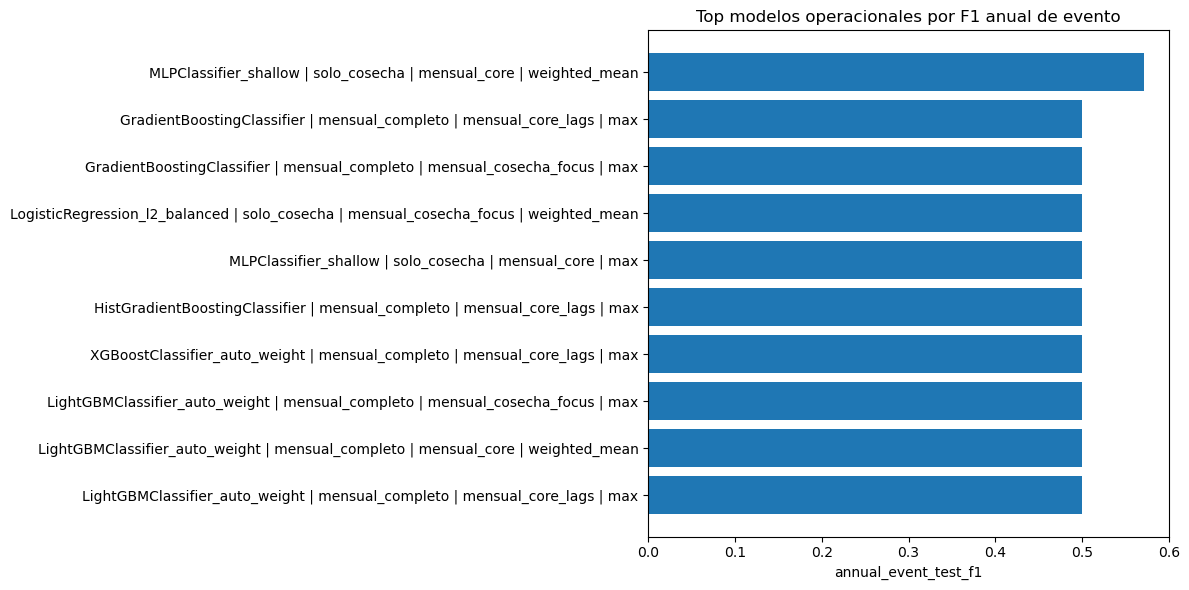

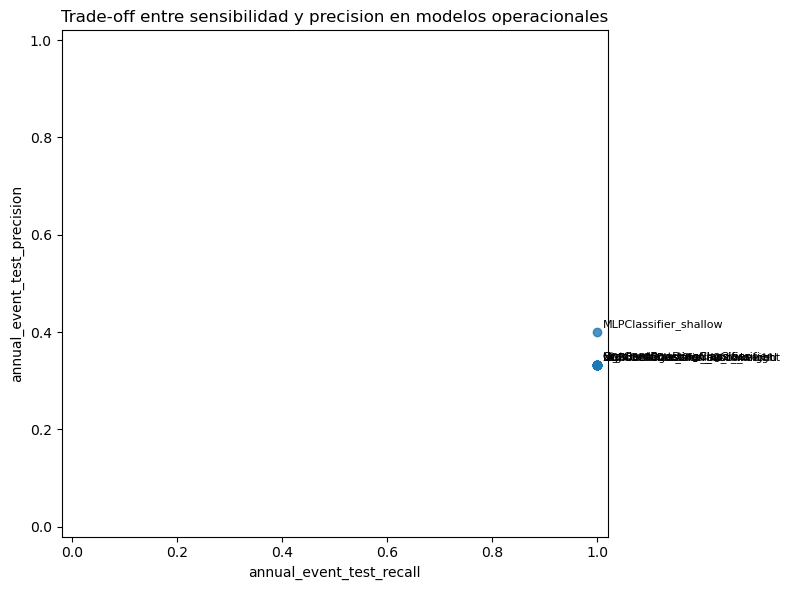

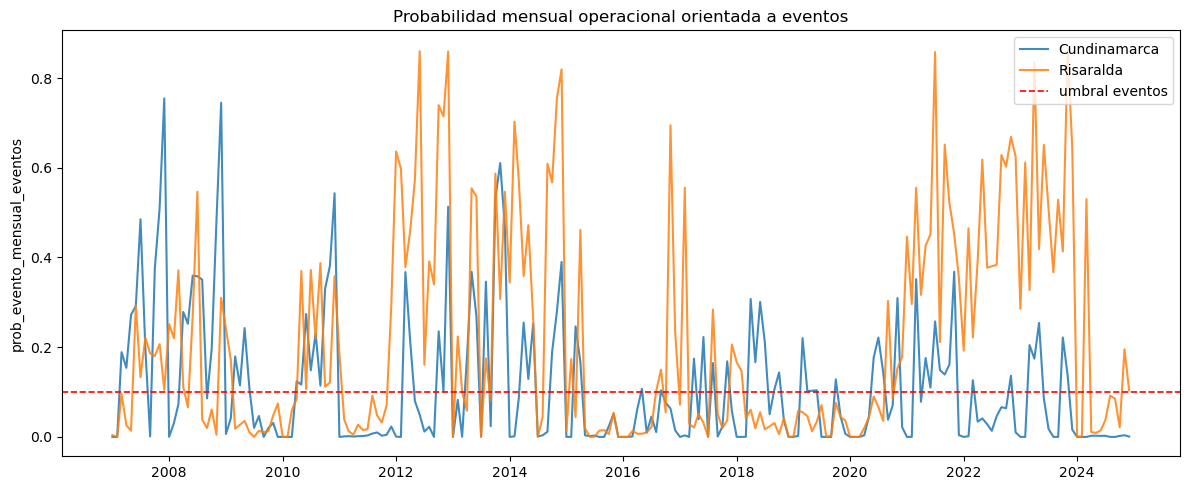

In [19]:
if MATPLOTLIB_AVAILABLE and len(test_results_df) > 0:
    plot_df = test_results_df.head(10).copy()
    labels = plot_df['model_name'] + ' | ' + plot_df['sample_name'] + ' | ' + plot_df['feature_set'] + ' | ' + plot_df['annual_aggregation']
    plt.figure(figsize=(12, 6))
    plt.barh(labels, plot_df['annual_event_test_f1'])
    plt.gca().invert_yaxis()
    plt.xlabel('annual_event_test_f1')
    plt.title('Top modelos operacionales por F1 anual de evento')
    plt.tight_layout()
    plt.show()

if MATPLOTLIB_AVAILABLE and len(test_results_df) > 0:
    scatter_df = event_priority_models.head(20).copy()
    plt.figure(figsize=(8, 6))
    plt.scatter(scatter_df['annual_event_test_recall'], scatter_df['annual_event_test_precision'], alpha=0.8)
    for _, row in scatter_df.head(8).iterrows():
        plt.text(row['annual_event_test_recall'] + 0.01, row['annual_event_test_precision'] + 0.01, row['model_name'], fontsize=8)
    plt.xlabel('annual_event_test_recall')
    plt.ylabel('annual_event_test_precision')
    plt.title('Trade-off entre sensibilidad y precision en modelos operacionales')
    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 1.02)
    plt.tight_layout()
    plt.show()

if MATPLOTLIB_AVAILABLE and len(score_operacional_mensual_clasificacion) > 0:
    plot_score = score_operacional_mensual_clasificacion.loc[
        score_operacional_mensual_clasificacion['departamento'].isin(['Cundinamarca', 'Risaralda'])
    ].copy()
    plt.figure(figsize=(12, 5))
    for depto, grp in plot_score.groupby('departamento'):
        plt.plot(grp['fecha'], grp['prob_evento_mensual_eventos'], label=depto, alpha=0.85)
    plt.axhline(float(best_event['threshold_used']), color='red', linestyle='--', linewidth=1.2, label='umbral eventos')
    plt.title('Probabilidad mensual operacional orientada a eventos')
    plt.ylabel('prob_evento_mensual_eventos')
    plt.legend()
    plt.tight_layout()
    plt.show()


## Exportacion de productos analiticos

La fase operacional deja salidas para tres propositos complementarios:

- comparacion metodologica de modelos,
- soporte al informe tecnico,
- insumo directo para dashboard, alerta y decisiones posteriores de trigger.


In [20]:
export_status = []

objects_to_export = [
    ('dependencias_detectadas.csv', DEPENDENCIES),
    ('feature_sets_utilizados.csv', feature_set_summary),
    ('resumen_folds_temporales.csv', fold_summary),
    ('resumen_cv_modelos.csv', cv_results_df),
    ('resumen_test_modelos.csv', test_results_df),
    ('resumen_test_modelos_priorizando_eventos.csv', event_priority_models),
    ('top_modelos_operacionales.csv', top_general),
    ('modelos_operacionales_priorizando_eventos.csv', top_events),
    ('predicciones_mensuales_holdout.csv', monthly_predictions_df),
    ('predicciones_anualizadas_holdout.csv', annualized_predictions_df),
    ('score_operacional_mensual_clasificacion.csv', score_operacional_mensual_clasificacion),
    ('trazabilidad_operacional_prototipo.csv', trazabilidad_operacional_prototipo),
    ('candidatos_operacionales_por_objetivo.csv', candidatos_operacionales if 'candidatos_operacionales' in locals() else pd.DataFrame()),
    ('resumen_candidatos_operacionales.csv', resumen_candidatos_operacionales),
    ('plan_pendientes_prototipo_operacional.csv', plan_pendientes_prototipo_operacional),
]

for filename, obj in objects_to_export:
    try:
        if obj is not None and len(obj) > 0:
            obj.to_csv(OUTPUT_DIR / filename, index=False, encoding='utf-8')
            export_status.append({'archivo': filename, 'estado': 'ok'})
        else:
            export_status.append({'archivo': filename, 'estado': 'sin_datos'})
    except Exception as exc:
        export_status.append({'archivo': filename, 'estado': f'fallo: {exc}'})

config_payload = {
    'target': TARGET,
    'train_end_year': TRAIN_END_YEAR,
    'test_years': [TEST_START_YEAR, TEST_END_YEAR],
    'thresholds': THRESHOLDS,
    'aggregation_strategies': AGGREGATION_STRATEGIES,
    'samples': list(sample_catalog.keys()),
    'feature_sets': {k: len(v) for k, v in feature_sets.items()},
    'n_models': len(model_specs),
}

try:
    with open(OUTPUT_DIR / 'config_experimento.json', 'w', encoding='utf-8') as f:
        json.dump(config_payload, f, ensure_ascii=False, indent=2)
    export_status.append({'archivo': 'config_experimento.json', 'estado': 'ok'})
except Exception as exc:
    export_status.append({'archivo': 'config_experimento.json', 'estado': f'fallo: {exc}'})

try:
    with open(OUTPUT_DIR / 'run_log_11_1_operacional_mensual_clasificacion.txt', 'w', encoding='utf-8') as f:
        f.write('\n'.join(RUN_LOG))
    export_status.append({'archivo': 'run_log_11_1_operacional_mensual_clasificacion.txt', 'estado': 'ok'})
except Exception as exc:
    export_status.append({'archivo': 'run_log_11_1_operacional_mensual_clasificacion.txt', 'estado': f'fallo: {exc}'})

export_status_df = pd.DataFrame(export_status)
display(export_status_df)


,archivo,estado
0,dependencias_detectadas.csv,ok
1,feature_sets_utilizados.csv,ok
2,resumen_folds_temporales.csv,ok
3,resumen_cv_modelos.csv,ok
4,resumen_test_modelos.csv,ok
5,resumen_test_modelos_priorizando_eventos.csv,ok
6,top_modelos_operacionales.csv,ok
7,modelos_operacionales_priorizando_eventos.csv,ok
8,predicciones_mensuales_holdout.csv,ok
9,predicciones_anualizadas_holdout.csv,ok


In [21]:
summary_rows = []
if len(test_results_df) > 0:
    summary_rows.extend([
        {'tema': 'mejor_modelo_operacional_general', 'lectura': f"{best_general['model_name']} | {best_general['sample_name']} | {best_general['feature_set']} | {best_general['annual_aggregation']}"},
        {'tema': 'mejor_f1_anual_evento', 'lectura': f"{best_general['annual_event_test_f1']:.4f}"},
        {'tema': 'mejor_balanced_accuracy_anual', 'lectura': f"{best_general['annual_event_test_balanced_accuracy']:.4f}"},
        {'tema': 'umbral_mejor_modelo_general', 'lectura': f"{float(best_general['threshold_used']):.2f}"},
        {'tema': 'mejor_modelo_eventos', 'lectura': f"{best_event['model_name']} | {best_event['sample_name']} | {best_event['feature_set']} | {best_event['annual_aggregation']}"},
        {'tema': 'recall_mejor_modelo_eventos', 'lectura': f"{best_event['annual_event_test_recall']:.4f}"},
        {'tema': 'f1_mejor_modelo_eventos', 'lectura': f"{best_event['annual_event_test_f1']:.4f}"},
    ])
summary_df = pd.DataFrame(summary_rows)
display(summary_df)
print('Notebook 11.1 listo.')


,tema,lectura
0,mejor_modelo_operacional_general,MLPClassifier_shallow | solo_cosecha | mensual...
1,mejor_f1_anual_evento,0.5714
2,mejor_balanced_accuracy_anual,0.7500
3,umbral_mejor_modelo_general,0.10
4,mejor_modelo_eventos,MLPClassifier_shallow | solo_cosecha | mensual...
5,recall_mejor_modelo_eventos,1.0000
6,f1_mejor_modelo_eventos,0.5714


Notebook 11.1 listo.
